<a href="https://colab.research.google.com/github/s-imiks/Kaggle-exercises/blob/main/Cats%20vs%20Dogs%20CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Introduction to image processing

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
import os

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

Importing my data

In [2]:
from google.colab import files
uploaded = files.upload()




Saving archive (4).zip to archive (4) (2).zip


Extract Dataset

In [3]:
import zipfile

zip_filename = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('/content')

print("Dataset extracted successfully")

Dataset extracted successfully


Locate dataset folder

In [4]:
dataset_path="/content/cats_set"
print(os.listdir(dataset_path))

['cat.4459.jpg', 'cat.4481.jpg', 'cat.4109.jpg', 'cat.4228.jpg', 'cat.4095.jpg', 'cat.4088.jpg', 'cat.4275.jpg', 'cat.4305.jpg', 'cat.4379.jpg', 'cat.4289.jpg', 'cat.4173.jpg', 'cat.4467.jpg', 'cat.4120.jpg', 'cat.4085.jpg', 'cat.4412.jpg', 'cat.4169.jpg', 'cat.4493.jpg', 'cat.4158.jpg', 'cat.4171.jpg', 'cat.4457.jpg', 'cat.4303.jpg', 'cat.4048.jpg', 'cat.4259.jpg', 'cat.4312.jpg', 'cat.4165.jpg', 'cat.4338.jpg', 'cat.4239.jpg', 'cat.4187.jpg', 'cat.4434.jpg', 'cat.4490.jpg', 'cat.4355.jpg', 'cat.4024.jpg', 'cat.4345.jpg', 'cat.4034.jpg', 'cat.4399.jpg', 'cat.4432.jpg', 'cat.4318.jpg', 'cat.4026.jpg', 'cat.4046.jpg', 'cat.4123.jpg', 'cat.4090.jpg', 'cat.4384.jpg', 'cat.4216.jpg', 'cat.4344.jpg', 'cat.4381.jpg', 'cat.4437.jpg', 'cat.4377.jpg', 'cat.4343.jpg', 'cat.4386.jpg', 'cat.4451.jpg', 'cat.4329.jpg', 'cat.4362.jpg', 'cat.4298.jpg', 'cat.4199.jpg', 'cat.4198.jpg', 'cat.4404.jpg', 'cat.4210.jpg', 'cat.4160.jpg', 'cat.4285.jpg', 'cat.4385.jpg', 'cat.4339.jpg', 'cat.4396.jpg', 'cat.40

Count Classes

In [5]:
class_names = sorted(os.listdir(dataset_path))
print(class_names)
print(len(class_names))


['cat.4001.jpg', 'cat.4002.jpg', 'cat.4003.jpg', 'cat.4004.jpg', 'cat.4005.jpg', 'cat.4006.jpg', 'cat.4007.jpg', 'cat.4008.jpg', 'cat.4009.jpg', 'cat.4010.jpg', 'cat.4011.jpg', 'cat.4012.jpg', 'cat.4013.jpg', 'cat.4014.jpg', 'cat.4015.jpg', 'cat.4016.jpg', 'cat.4017.jpg', 'cat.4018.jpg', 'cat.4019.jpg', 'cat.4020.jpg', 'cat.4021.jpg', 'cat.4022.jpg', 'cat.4023.jpg', 'cat.4024.jpg', 'cat.4025.jpg', 'cat.4026.jpg', 'cat.4027.jpg', 'cat.4028.jpg', 'cat.4029.jpg', 'cat.4030.jpg', 'cat.4031.jpg', 'cat.4032.jpg', 'cat.4033.jpg', 'cat.4034.jpg', 'cat.4035.jpg', 'cat.4036.jpg', 'cat.4037.jpg', 'cat.4038.jpg', 'cat.4039.jpg', 'cat.4040.jpg', 'cat.4041.jpg', 'cat.4042.jpg', 'cat.4043.jpg', 'cat.4044.jpg', 'cat.4045.jpg', 'cat.4046.jpg', 'cat.4047.jpg', 'cat.4048.jpg', 'cat.4049.jpg', 'cat.4050.jpg', 'cat.4051.jpg', 'cat.4052.jpg', 'cat.4053.jpg', 'cat.4054.jpg', 'cat.4055.jpg', 'cat.4056.jpg', 'cat.4057.jpg', 'cat.4058.jpg', 'cat.4059.jpg', 'cat.4060.jpg', 'cat.4061.jpg', 'cat.4062.jpg', 'cat.40

In [6]:
import os

print(os.listdir("/content"))

['.config', 'cats_set', 'archive (4) (2).zip', 'archive (4) (1).zip', 'cutie🥰.jpg', 'girl.jpg', 'girl (1).jpg', 'download (12).jpg', 'dogs_set', 'dataset', 'image_classifier.keras', 'archive (4).zip', 'sample_data']


In [7]:
cats_path = "/content/cats_set"
dogs_path = "/content/dogs_set"

print(os.listdir(cats_path)[:5])
print(os.listdir(dogs_path)[:5])

['cat.4459.jpg', 'cat.4481.jpg', 'cat.4109.jpg', 'cat.4228.jpg', 'cat.4095.jpg']
['dog.4070.jpg', 'dog.4024.jpg', 'dog.4156.jpg', 'dog.4216.jpg', 'dog.4193.jpg']


In [8]:
import os
import shutil

base_dir = "/content/dataset"

cats_dir = os.path.join(base_dir, "cats")
dogs_dir = os.path.join(base_dir, "dogs")

os.makedirs(cats_dir, exist_ok=True)
os.makedirs(dogs_dir, exist_ok=True)

# Move cats
for file in os.listdir("/content/cats_set"):
    shutil.copy(os.path.join("/content/cats_set", file),
                os.path.join(cats_dir, file))

# Move dogs
for file in os.listdir("/content/dogs_set"):
    shutil.copy(os.path.join("/content/dogs_set", file),
                os.path.join(dogs_dir, file))

print("Dataset reorganized successfully!")

Dataset reorganized successfully!


In [9]:
print(os.listdir("/content/dataset"))

['dogs', 'cats', 'others']


In [10]:
dataset_path = "/content/dataset"

class_names = sorted(os.listdir(dataset_path))
print(class_names)
print(len(class_names))

['cats', 'dogs', 'others']
3


Count images per class

In [11]:
for cls in class_names:
    count=len(os.listdir(os.path.join(dataset_path,cls)))
    print(cls,count)


cats 500
dogs 500
others 1


Create training datase

In [12]:
batch_size=32
img_height=180
img_width=180

train_ds=tf.keras.utils.image_dataset_from_directory(
dataset_path,
validation_split=0.2,
subset="training",
seed=123,
image_size=(img_height,img_width),
batch_size=batch_size)


Found 1001 files belonging to 3 classes.
Using 801 files for training.


Create Validation dataset

In [13]:
val_ds=tf.keras.utils.image_dataset_from_directory(
dataset_path,
validation_split=0.2,
subset="validation",
seed=123,
image_size=(img_height,img_width),
batch_size=batch_size)


Found 1001 files belonging to 3 classes.
Using 200 files for validation.


Obtain class names

In [14]:
class_names=train_ds.class_names
print(class_names)


['cats', 'dogs', 'others']


Display sample images

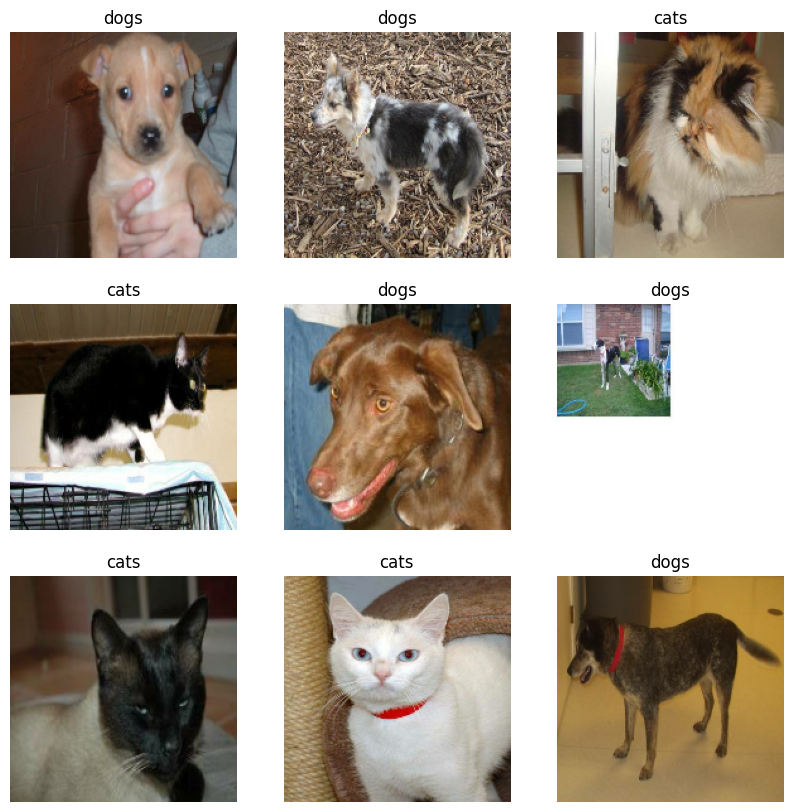

In [15]:
plt.figure(figsize=(10,10))
for images,labels in train_ds.take(1):
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")


Improve performance

In [16]:
import tensorflow as tf

# Re-defining dependencies to ensure they are available in this cell
dataset_path = "/content/dataset"
batch_size=32
img_height=180
img_width=180

# Re-creating train_ds and val_ds before applying performance optimizations
train_ds = tf.keras.utils.image_dataset_from_directory(
dataset_path,
validation_split=0.2,
subset="training",
seed=123,
image_size=(img_height,img_width),
batch_size=batch_size)

val_ds=tf.keras.utils.image_dataset_from_directory(
dataset_path,
validation_split=0.2,
subset="validation",
seed=123,
image_size=(img_height,img_width),
batch_size=batch_size)

AUTOTUNE=tf.data.AUTOTUNE
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds=val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 1001 files belonging to 3 classes.
Using 801 files for training.
Found 1001 files belonging to 3 classes.
Using 200 files for validation.


Build CNN Model

In [17]:

num_classes=len(class_names)

model=keras.Sequential([
layers.Rescaling(1./255,input_shape=(180,180,3)),
layers.Conv2D(16,3,padding='same',activation='relu'),
layers.MaxPooling2D(),
layers.Conv2D(32,3,padding='same',activation='relu'),
layers.MaxPooling2D(),
layers.Conv2D(64,3,padding='same',activation='relu'),
layers.MaxPooling2D(),
layers.Flatten(),
layers.Dense(128,activation='relu'),
layers.Dense(num_classes)])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Compile Model

In [18]:
model.compile(
optimizer='adam',
loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
metrics=['accuracy'])


Model Summary

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,027 (15.22 MB)

 Trainable params: 3,989,027 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

Train Model

In [20]:
epochs=10
history=model.fit(train_ds,validation_data=val_ds,epochs=epochs)


Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.4981 - loss: 0.8893 - val_accuracy: 0.4350 - val_loss: 1.2358
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.5281 - loss: 0.7290 - val_accuracy: 0.6250 - val_loss: 0.6714
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.5880 - loss: 0.6713 - val_accuracy: 0.6900 - val_loss: 0.6248
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.7129 - loss: 0.5862 - val_accuracy: 0.6350 - val_loss: 0.6382
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.7366 - loss: 0.5181 - val_accuracy: 0.6600 - val_loss: 0.6683
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.8102 - loss: 0.4194 - val_accuracy: 0.6700 - val_loss: 0.6872
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8614 - loss: 0.3258 - val_accuracy: 0.6850 - val_loss: 0.7348
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.8814 - loss: 0.3041 - val_accuracy: 0.6750 - val_loss:

Plot Accuracy

In [21]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']


Plot Loss

In [22]:
loss=history.history['loss']
val_loss=history.history['val_loss']


Save Model

In [23]:
model.save("image_classifier.keras")

Uploading test image

In [24]:
uploaded=files.upload()

Saving cat.jpg to cat.jpg


Load test image

In [25]:
 test_image_path=list(uploaded.keys())[0]
img=tf.keras.utils.load_img(test_image_path,target_size=(180,180))


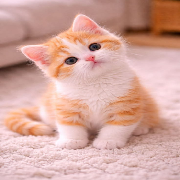

In [26]:
from IPython.display import display

display(img)

Convert image to array

In [27]:
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

print(img_array.shape)

(1, 180, 180, 3)


Predict image class

In [28]:
prediction = model.predict(img_array)
score = tf.nn.softmax(prediction[0])

predicted_class = class_names[np.argmax(score)]
confidence = 100 * np.max(score)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


Display results

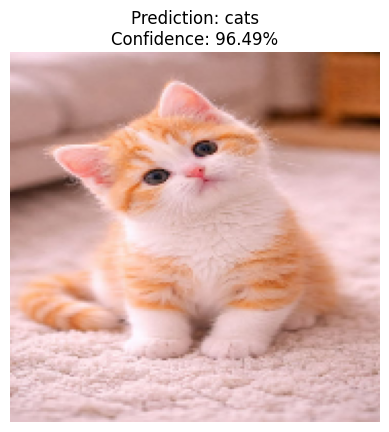

In [29]:
plt.imshow(img)
plt.axis("off")

plt.title(
    f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%"
)

plt.show()


Verify threshold

In [30]:
if confidence < 70:
    print("Unknown image (not cat or dog)")
else:
    print("Predicted Class:", predicted_class)
    print("Confidence: {:.2f}%".format(confidence))

Predicted Class: cats
Confidence: 96.49%


Test image 2

In [31]:
from google.colab import files
uploaded = files.upload()

Saving dog.jpg to dog.jpg


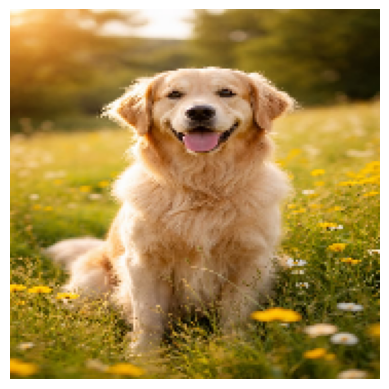

In [32]:
test_image_path = list(uploaded.keys())[0]

img = tf.keras.utils.load_img(test_image_path, target_size=(180,180))

plt.imshow(img)
plt.axis("off")
plt.show()

Prediction

In [33]:
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

prediction = model.predict(img_array)
score = tf.nn.softmax(prediction[0])

predicted_class = class_names[np.argmax(score)]
confidence = 100 * np.max(score)

print("Predicted Class:", predicted_class)
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted Class: dogs
Confidence: 89.88262


Test on random image


In [34]:
uploaded = files.upload()

Saving girl.jpg to girl (2).jpg


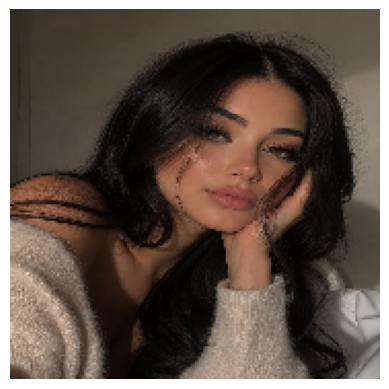

In [35]:
test_image_path = list(uploaded.keys())[0]

img = tf.keras.utils.load_img(test_image_path, target_size=(180,180))

plt.imshow(img)
plt.axis("off")
plt.show()

In [36]:
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

prediction = model.predict(img_array)
score = tf.nn.softmax(prediction[0])

predicted_class = class_names[np.argmax(score)]
confidence = 100 * np.max(score)

print("Predicted Class:", predicted_class)
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
Predicted Class: others
Confidence: 53.361786
